In [1]:
%pip install python-dotenv langchain-groq langgraph
from langchain_core.messages import HumanMessage, ToolMessage
from langchain.tools import tool
from langchain_core.prompts import ChatPromptTemplate
from dotenv import load_dotenv
import os

load_dotenv()

if os.getenv("GROQ_API_KEY"):
    print("Groq API key is set.")
else:
    raise ValueError("Groq API key is not set.")
from langchain_groq import ChatGroq

model = ChatGroq(
    model="llama-3.3-70b-versatile"
)
model
model.invoke("tell me what should be do if our gf is angrey").content

Note: you may need to restart the kernel to use updated packages.


c:\Users\puroh\Desktop\langgraph-tutoril\.venv\Scripts\python.exe: No module named pip


Groq API key is set.


'A very common and delicate situation! If your girlfriend is angry, here are some steps you can take to help calm her down and resolve the issue:\n\n1. **Stay calm**: It\'s essential to remain calm and composed, even if your girlfriend is upset. Avoid getting defensive or matching her level of anger, as this can escalate the situation.\n2. **Listen actively**: Give your girlfriend your full attention, and listen to what she has to say. Try to understand her perspective and the reasons behind her anger.\n3. **Acknowledge her feelings**: Show empathy by acknowledging her emotions and validating her feelings. You can say something like, "I can see that you\'re really upset, and I\'m sorry that you\'re feeling this way."\n4. **Give her space (if needed)**: If your girlfriend needs some space, respect her boundaries and give her the space she needs. However, if she wants to talk, be present and listen to her.\n5. **Communicate openly**: Once she\'s ready to talk, have an open and honest con

In [3]:
from pydantic import BaseModel, Field
from typing import List, TypedDict, Literal

class llm_schema(BaseModel):
    funny_flag: Literal["funny","not funny"] = Field(description="Whether the joke is funny or not")
    feedback: str = Field(description="Feedback on the joke")

llm_with_schema = model.with_structured_output(llm_schema)

In [4]:
class graph_schema(TypedDict):

    topic: str
    joke: str
    funny_flag: str
    feedback: str
    max_iterations: int

In [6]:
def generate_node(state: graph_schema) -> graph_schema:
    

    topic = state['topic']

    if state['feedback']: # Not first iteration, generate a joke based on feedback
        response = model.invoke(f"Please modify the following joke {state['joke']} based on the following feedback: {state['feedback']}") 
    else: # First iteration, generate a joke
        response = model.invoke("Create only one joke about the following topic: " + topic)

    
    state['joke'] = response.content 
    return state

In [7]:

def evaluate_node(state: graph_schema) -> graph_schema: 

    joke = state['joke']
    iteration = state['max_iterations']

    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a comedy critic. Your job is to evaluate the following joke and provide feedback on how to make it funnier."),
        ("user", f"Evaluate the following joke: {joke}\nRespond with 'funny' or 'not_funny' and provide feedback if it's not funny.")
    ])

    chain = prompt | llm_with_schema
    response = chain.invoke({"joke": joke})

    state['funny_flag'] = response.funny_flag
    state['feedback'] = response.feedback
    state['max_iterations'] = iteration + 1

    return state

In [8]:
def check_iteration(state: graph_schema) -> str:

    iteration = state['max_iterations']

    if iteration <= 5 and state['funny_flag'] != "funny":
        return "evaluate_node"
    else:
        return "end"

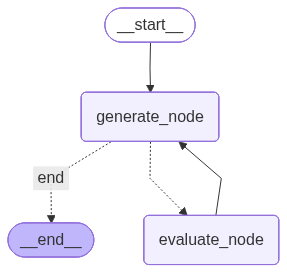

In [9]:
from langgraph.graph import StateGraph, START, END 


graph = StateGraph(graph_schema)

graph.add_node("generate_node", generate_node)
graph.add_node("evaluate_node", evaluate_node)

graph.add_edge(START, "generate_node")
graph.add_conditional_edges("generate_node", check_iteration, {"evaluate_node": "evaluate_node", "end": END})
graph.add_edge("evaluate_node", "generate_node")
graph.add_edge("generate_node", END)

evaluator_graph = graph.compile()

from IPython.display import Image, display

# You could see the errors with the below command
Image(evaluator_graph.get_graph().draw_mermaid_png())

In [10]:

for chunk in evaluator_graph.stream(
    {
        "topic": "Cars",
        "joke": "",
        "funny_flag": "",
        "feedback": "",
        "max_iterations": 0
    },
    stream_mode="updates"
):
    print(chunk)

{'generate_node': {'topic': 'Cars', 'joke': 'Why did the car go to the doctor? Because it was feeling a little "car-sick"!', 'funny_flag': '', 'feedback': '', 'max_iterations': 0}}
{'evaluate_node': {'topic': 'Cars', 'joke': 'Why did the car go to the doctor? Because it was feeling a little "car-sick"!', 'funny_flag': 'not funny', 'feedback': "The joke relies on a common play on words, but it's been done before and might not be original or surprising enough to elicit laughter. Consider adding more context or an unexpected twist to make it more engaging.", 'max_iterations': 1}}
{'generate_node': {'topic': 'Cars', 'joke': 'Here\'s a modified version of the joke that adds more context and an unexpected twist:\n\nWhy did the car\'s GPS go to therapy? Because it was feeling a little "car-sick" after constantly being told to "recalculate" its life choices! It turns out, the GPS had a fear of being replaced by a newer model, and its anxiety was causing it to take a lot of "wrong turns" in lif